# Week2-1: 4D MCMC from scratch

Now we have the position of all the stars in the 1x1 degree on the sky. \
We assume that each star could belong ot the dwarf galaxy that follows a Gaussian distribution or a the MW forground that follows a flat distribution. \
Now we will determine the 2D distribution of dwarf galaxies on the sky, as well as the member probability of each star. 



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import corner

%matplotlib inline

In [14]:
data_path = '../data/Dwarfs/'
res_path = '../result/'
fig_path = '../figure/'



df = pd.read_csv(data_path+'Dwarf_01')

df

,X_pc,Y_pc,vr,d_vr,FeH,d_FeH,flag
0,862.072,-267.376,-2.177,4.46,-2.13,0.23,1
1,-108.093,-117.081,999.000,999.00,-2.08,0.26,1
2,254.962,-410.536,999.000,999.00,-2.13,0.30,1
3,337.575,-492.211,999.000,999.00,-2.11,0.25,1
4,-329.291,-491.952,999.000,999.00,-2.44,0.25,1
...,...,...,...,...,...,...,...
2131,4776.443,976.284,999.000,999.00,-0.39,0.21,0
2132,4899.896,-3715.461,-55.157,4.43,-0.59,0.24,0
2133,-2399.821,-3014.935,999.000,999.00,-0.73,0.27,0
2134,56.823,2569.389,999.000,999.00,-0.77,0.24,0


(-2000.0, 2000.0)

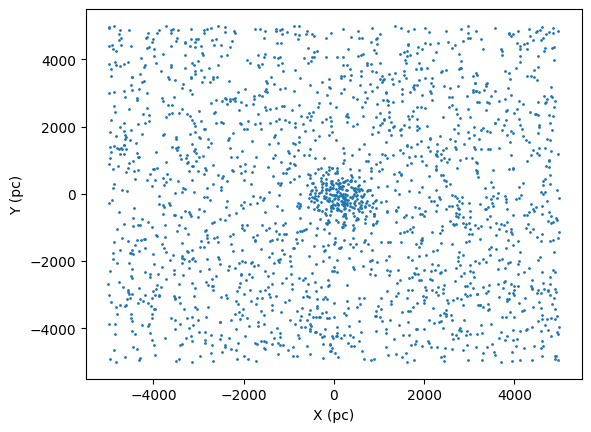

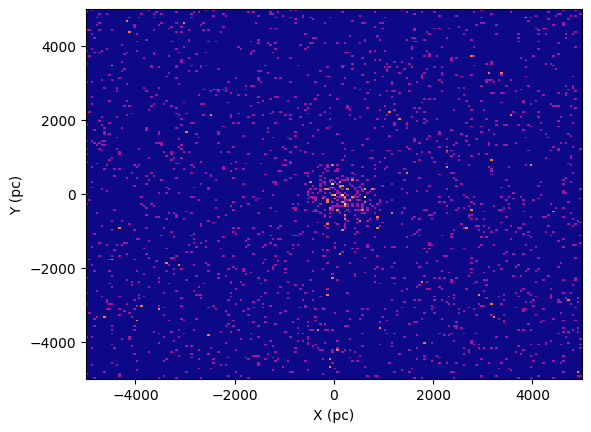

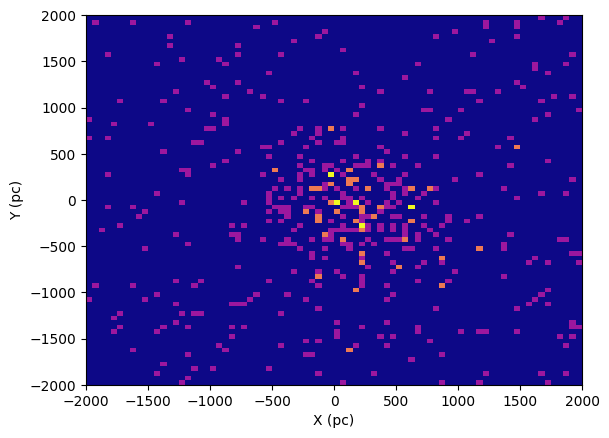

In [3]:
plt.figure()
plt.scatter(df['X_pc'], df['Y_pc'], s=1)

plt.xlabel("X (pc)")
plt.ylabel("Y (pc)")


plt.figure()
plt.hist2d(df['X_pc'], df['Y_pc'], bins=200, cmap='plasma')

plt.xlabel("X (pc)")
plt.ylabel("Y (pc)")


plt.figure()
plt.hist2d(df['X_pc'], df['Y_pc'], bins=200, cmap='plasma')

plt.xlabel("X (pc)")
plt.ylabel("Y (pc)")

plt.xlim(-2000, 2000)
plt.ylim(-2000, 2000)


In [4]:
def log_Likelihood(theta, x, y):

    xc, yc, sigma, f = theta

    # Calculate the likelihood of being in the dwarf galaxy
    L1 = f/(2*np.pi*sigma**2.0)*np.exp(-0.5*((x-xc)**2.+(y-yc)**2.)/sigma**2.)
    # Calculate the likelihood of being in the MW foreground
    L2 = (1-f)/10000**2.
    
    logL = np.sum(np.log(L1 + L2))

    return logL


In [9]:
xc0 = 0
yc0 = 0
sigma0 = 100
f0=0.1
param0 = xc0, yc0, sigma0, f0

logL0 = log_Likelihood(param0, df['X_pc'], df['Y_pc'])

# refine the following steps based on the uncertainties of the results
step_xc = 40
step_yc = 40
step_sigma = 30
step_f = 0.005
nsteps = 50000

samples = np.zeros((nsteps, 6))
accept = 1

In [11]:
for i in range(nsteps):

    param1 = param0
    logL1 = logL0

    samples[i, :4] = param1
    samples[i, 4] = logL1
    samples[i, 5] = accept

    accept = 0

    xc1, yc1, sigma1, f1 = param1
    xc1 = xc1 + np.random.normal(0, step_xc)   
    yc1 = yc1 + np.random.normal(0, step_yc)
    sigma1 = sigma1 + np.random.normal(0, step_sigma)
    f1 = f1 + np.random.normal(0, step_f)
    param1 = xc1, yc1, sigma1, f1

    if (0 < f1 < 1) & (0 <sigma1 < 1000):
    
        logL1 = log_Likelihood(param1,  df['X_pc'], df['Y_pc'])      

        if logL1 > logL0:

            param0 = param1
            logL0 = logL1
            accept = 1

        else:

            a = np.random.uniform(0, 1)
            if (logL1-logL0) > np.log(a):

                param0 = param1
                logL0 = logL1
                accept = 1

In [12]:
# Check the acceptance rate of the MCMC (should be around 20%)
ind_accept = samples[:, -1] == 1
print ("Dwarf%02d acceptance rate"%1, len(samples[ind_accept, -1])/nsteps)


Dwarf01 acceptance rate 0.29636


In [15]:
samples =  samples[int(nsteps*0.1):]
np.savetxt(res_path+'Dwarf_%02d_4D_MCMC_chain.txt'%1, samples)

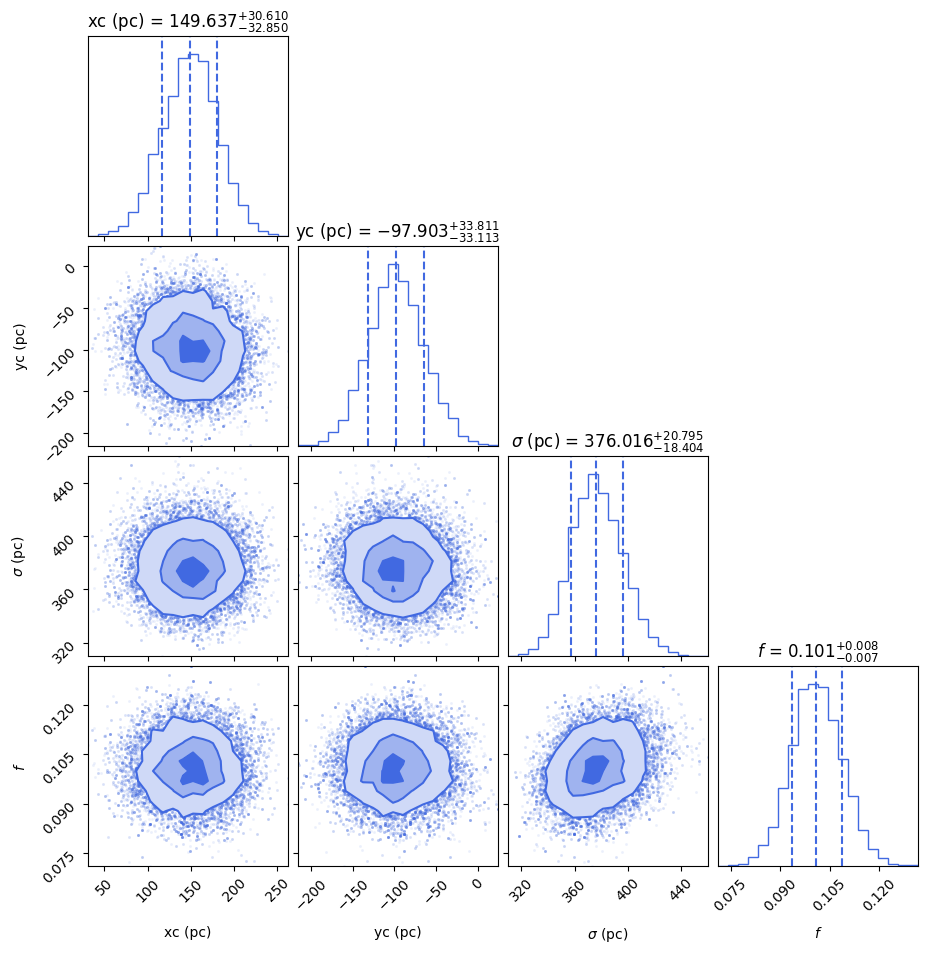

In [17]:
fig = corner.corner(
    samples[:,:4],
    labels=[r"xc (pc)", r"yc (pc)", r"$\sigma$ (pc)", r"$f$"],
    # truths=[mvr1_true, dvr1_true, mvr2_true, dvr2_true, f_true],  # optional
    show_titles=True,
    title_fmt=".3f",
    quantiles=[0.16, 0.5, 0.84],
    levels=(0.16, 0.5, 0.84),
    color="royalblue",
    fill_contours=True
)

## Calculating the membership probability

In [19]:
def prob_member(theta, x, y):

    xc, yc, sigma, f = theta

    # Calculate the likelihood of being in the dwarf galaxy
    p1 = 1/(2*np.pi*sigma**2.0)*np.exp(-0.5*((x-xc)**2.+(y-yc)**2.)/sigma**2.)
    # Calculate the likelihood of being in the MW foreground
    p2 = 1/10000**2.
    
    prob = p1 / (p1 + p2)

    return prob


In [18]:
param_f = np.zeros(4)
for i in range(4):

    param_f[i] = np.percentile(samples[:,i], 50)
print (param_f)

[ 1.49637340e+02 -9.79034273e+01  3.76015862e+02  1.01019685e-01]


In [34]:
p_member = np.zeros(len(df))

p_member = prob_member(param_f, df['X_pc'], df['Y_pc'])



Text(0.5, 0, 'Probability of being a member of Dwarf01')

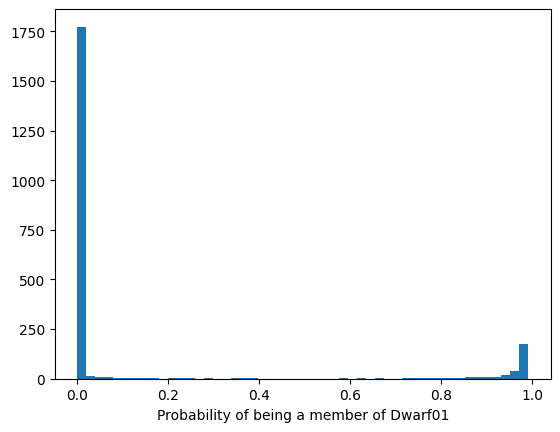

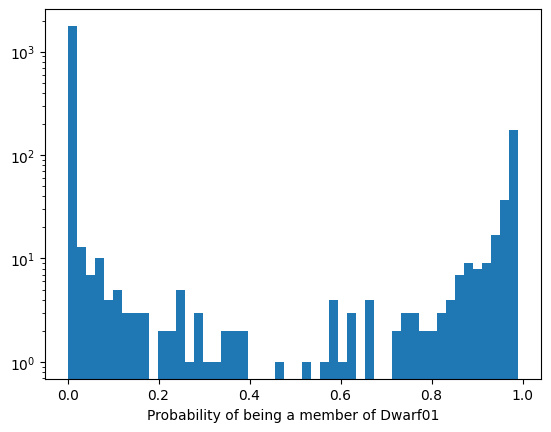

In [35]:
plt.figure()
plt.hist(p_member, bins=50);
plt.xlabel("Probability of being a member of Dwarf%02d"%1)

plt.figure()
plt.hist(p_member, bins=50);
plt.yscale("log")
plt.xlabel("Probability of being a member of Dwarf%02d"%1)

Text(0, 0.5, 'Y (pc)')

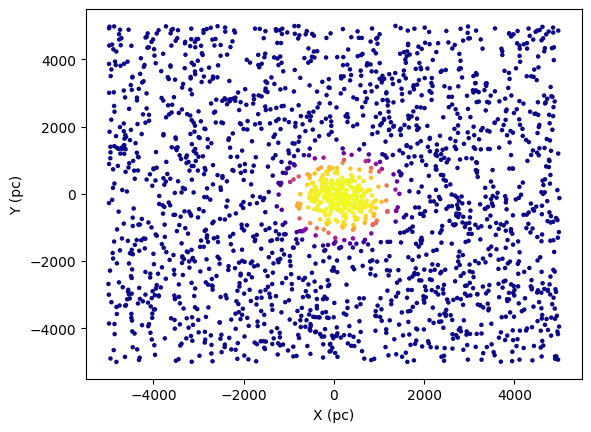

In [36]:
plt.figure()
plt.scatter(df['X_pc'], df['Y_pc'], c=df['P_member_position'], s=5, cmap='plasma')

plt.xlabel("X (pc)")
plt.ylabel("Y (pc)")